Cellule 1 : Les importations et la configuration
Dans cette première cellule, on ramène tous les outils dont on a besoin, notamment TensorFlow pour construire le réseau de neurones et Scikit-Learn pour mélanger/séparer nos données.

In [6]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import TensorBoard
import matplotlib.pyplot as plt

# Configuration de base
DATA_PATH = os.path.join('dataset')
sequence_length = 30 # Nos 30 images par mouvement

# --- DÉTECTION DYNAMIQUE ET TRI ALPHABÉTIQUE (TRÈS IMPORTANT !) ---
# Le 'sorted()' garantit que l'API et l'entraînement auront exactement les mêmes IDs
actions = np.array(sorted([name for name in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, name))]))
print(f"✅ Mots détectés et triés pour l'entraînement : {actions}")

# On crée un dictionnaire pour associer chaque mot à un numéro
label_map = {label:num for num, label in enumerate(actions)}
print(f"✅ Mapping des labels : {label_map}")

✅ Mots détectés et triés pour l'entraînement : ['bonjour' 'ça va']
✅ Mapping des labels : {'bonjour': 0, 'ça va': 1}


Cellule 2 : Chargement et formatage des données
Ici, on va parcourir tous tes fichiers .npy, les charger en mémoire, et préparer les "étiquettes" (labels) pour que l'IA sache quelle vidéo correspond à quel mot.

In [7]:
sequences, labels = [], []

for action in actions:
    dossier_action = os.path.join(DATA_PATH, action)
    
    # On récupère tous les vrais fichiers .npy (peu importe leur nom : 0.npy, 42.npy...)
    fichiers = [f for f in os.listdir(dossier_action) if f.endswith('.npy')]
    
    for fichier in fichiers:
        try:
            # On charge le fichier NumPy
            res = np.load(os.path.join(dossier_action, fichier))
            
            # --- SÉCURITÉ : VÉRIFICATION DU FORMAT HOLISTIC ---
            # On s'assure que le fichier contient bien 30 frames et 1662 points
            if res.shape == (30, 1662):
                sequences.append(res)
                labels.append(label_map[action])
            else:
                print(f"⚠️ Fichier ignoré (mauvais format) : {action}/{fichier} -> {res.shape}")
                
        except Exception as e:
            print(f"❌ Erreur avec le fichier {fichier} du mot {action} : {e}")

# X = nos vidéos (les points), y = nos réponses (les mots)
X = np.array(sequences)
y = to_categorical(labels).astype(int) # Transforme en format binaire compréhensible par l'IA

# On sépare les données : 95% pour apprendre, 5% pour tester
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

print(f"\n✅ Forme des données d'entraînement (Vidéos, Frames, Points) : {X_train.shape}")
print("👉 Le dernier chiffre DOIT être 1662 !")


✅ Forme des données d'entraînement (Vidéos, Frames, Points) : (49, 30, 1662)
👉 Le dernier chiffre DOIT être 1662 !


Cellule 3 : Construction de l'architecture LSTM
C'est ici qu'on construit notre réseau de neurones récurrent. Les couches LSTM vont analyser l'évolution des 126 points au fil des 30 frames pour comprendre la dynamique de ton geste.

In [8]:
model = Sequential()

# Première couche LSTM : elle lit les 30 frames de 1662 points
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(sequence_length, 1662)))
model.add(Dropout(0.2)) # On désactive 20% des neurones au hasard pour éviter que l'IA apprenne "par coeur" (overfitting)

# Deuxième couche LSTM
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(Dropout(0.2))

# Troisième couche LSTM (return_sequences=False car c'est la dernière étape d'analyse temporelle)
model.add(LSTM(64, return_sequences=False, activation='relu'))

# Couches de décision classiques
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Couche finale : autant de neurones que de mots à deviner
model.add(Dense(actions.shape[0], activation='softmax'))

# Compilation du modèle
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 30, 64)            442112    
                                                                 
 dropout_2 (Dropout)         (None, 30, 64)            0         
                                                                 
 lstm_4 (LSTM)               (None, 30, 128)           98816     
                                                                 
 dropout_3 (Dropout)         (None, 30, 128)           0         
                                                                 
 lstm_5 (LSTM)               (None, 64)                49408     
                                                                 
 dense_3 (Dense)             (None, 64)                4160      
                                                                 
 dense_4 (Dense)             (None, 32)               

Cellule 4 : L'entraînement !
On lance l'apprentissage. epochs=100 signifie que l'IA va repasser 100 fois sur tes données pour affiner ses connexions. Ça devrait aller très vite sur ton Mac (quelques secondes à peine).

(Tu vas voir les lignes défiler. L'objectif est que la valeur de loss baisse et que categorical_accuracy se rapproche de 1.0).

Début de l'entraînement...
Epoch 1/200
2/2 [==============================] - 2s 330ms/step - loss: 5.8839 - categorical_accuracy: 0.5714 - val_loss: 0.3688 - val_categorical_accuracy: 1.0000
Epoch 2/200
2/2 [==============================] - 0s 59ms/step - loss: 0.6425 - categorical_accuracy: 0.5714 - val_loss: 0.0012 - val_categorical_accuracy: 1.0000
Epoch 3/200
2/2 [==============================] - 0s 60ms/step - loss: 4.5049 - categorical_accuracy: 0.5306 - val_loss: 0.6970 - val_categorical_accuracy: 0.6667
Epoch 4/200
2/2 [==============================] - 0s 55ms/step - loss: 0.6523 - categorical_accuracy: 0.5306 - val_loss: 3.3671 - val_categorical_accuracy: 0.0000e+00
Epoch 5/200
2/2 [==============================] - 0s 60ms/step - loss: 3.6140 - categorical_accuracy: 0.3878 - val_loss: 1.7559 - val_categorical_accuracy: 0.0000e+00
Epoch 6/200
2/2 [==============================] - 0s 61ms/step - loss: 1.0144 - categorical_accuracy: 0.5102 - val_loss: 0.0602 - val_categoric

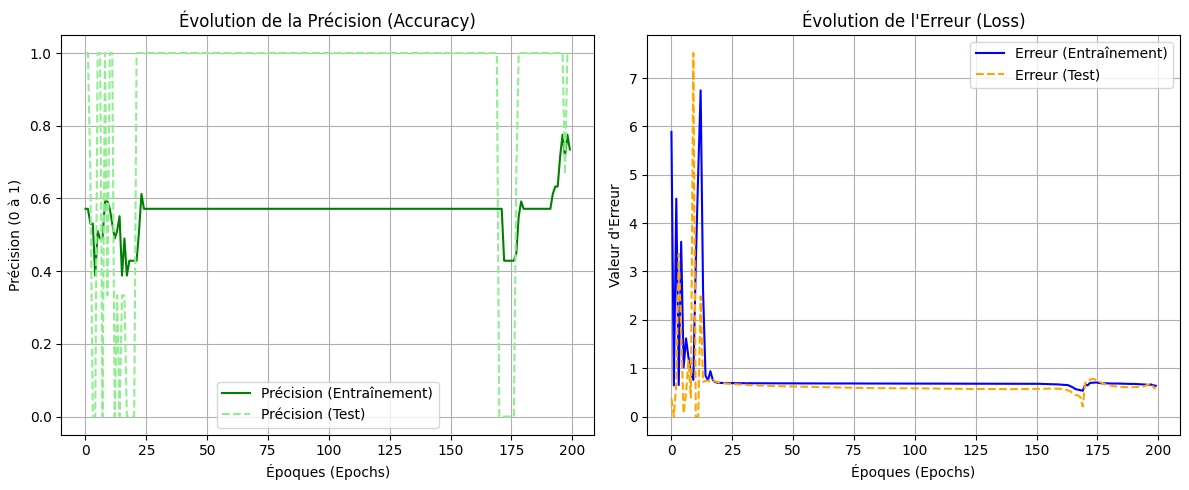

In [9]:
# L'entraînement avec sauvegarde de l'historique
print("Début de l'entraînement...")
history = model.fit(X_train, y_train, epochs=200, validation_data=(X_test, y_test))
print("Entraînement terminé !")

# ==========================================
# CRÉATION DES GRAPHIQUES (Style Article de Recherche)
# ==========================================
plt.figure(figsize=(12, 5))

# Graphique 1 : La Précision (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['categorical_accuracy'], label='Précision (Entraînement)', color='green')
plt.plot(history.history['val_categorical_accuracy'], label='Précision (Test)', color='lightgreen', linestyle='--')
plt.title('Évolution de la Précision (Accuracy)')
plt.xlabel('Époques (Epochs)')
plt.ylabel('Précision (0 à 1)')
plt.legend()
plt.grid(True)

# Graphique 2 : L'Erreur (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Erreur (Entraînement)', color='blue')
plt.plot(history.history['val_loss'], label='Erreur (Test)', color='orange', linestyle='--')
plt.title('Évolution de l\'Erreur (Loss)')
plt.xlabel('Époques (Epochs)')
plt.ylabel('Valeur d\'Erreur')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Cellule 5 : Sauvegarde du modèle
Une fois que l'IA est entraînée et performante, on sauvegarde son "cerveau" dans un fichier. C'est ce fichier que ton API Flask utilisera plus tard !

In [10]:
# Sauvegarde au format standard Keras
model.save('modele_lsf.keras')
print("Modèle sauvegardé avec succès sous le nom 'modele_lsf.keras' !")

# Petit test rapide sur une donnée de test pour voir si ça marche
res = model.predict(X_test)
prediction_index = np.argmax(res[0])
vrai_index = np.argmax(y_test[0])

print(f"L'IA a prédit : {actions[prediction_index]}")
print(f"La vraie réponse était : {actions[vrai_index]}")

Modèle sauvegardé avec succès sous le nom 'modele_lsf.keras' !
1/1 [==============================] - 0s 232ms/step
L'IA a prédit : bonjour
La vraie réponse était : bonjour
